# Figure 1 - self-configuration dynamics

This notebook regenerates the three quantitative panels in main-text Figure 1 (panels g-i): the parallel gradient signals, phase-shifter trajectories, and the two-mode interferogram acquired during optimization.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def find_repo_root() -> Path:
    """Find the repository whether Jupyter starts here or in notebooks/."""
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


ROOT = find_repo_root()
OUTPUT_DIR = ROOT / "figures" / "generated"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Compact, portable approximation of the paper's plotting style.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
from matplotlib import cm, colors
from matplotlib.ticker import FormatStrFormatter


## Load the final optimization run

In [2]:
DATA_FILE = ROOT / "data" / "figure1" / "ADAMopt_data_dict_2025-12-08_11-55-02.npy"
run = np.load(DATA_FILE, allow_pickle=True).item()["d_opt"]["test"]

history = np.asarray(run["history"], dtype=float)
channels = np.asarray(run["ps_channels"], dtype=int)
interferogram_x = np.asarray(run["interferograms_x_history"], dtype=float)
interferogram_y = np.asarray(run["interferograms_y_history"], dtype=float)

VOLTS_TO_RADIANS = 0.092
phase = history[:, 0, 0, :] * VOLTS_TO_RADIANS
gradient = history[:, 0, 1, :]

# The two heater types implement the internal (theta) and external (phi)
# phases of each 2x2 Mach-Zehnder interferometer.
theta_channels = {34, 36, 5, 10, 14, 18, 22}
phi_channels = {35, 42, 4, 7, 11, 15, 19}

print(f"Loaded {len(history)} optimizer iterations and {len(channels)} phase shifters.")

Loaded 200 optimizer iterations and 14 phase shifters.


## Plot panels g-i

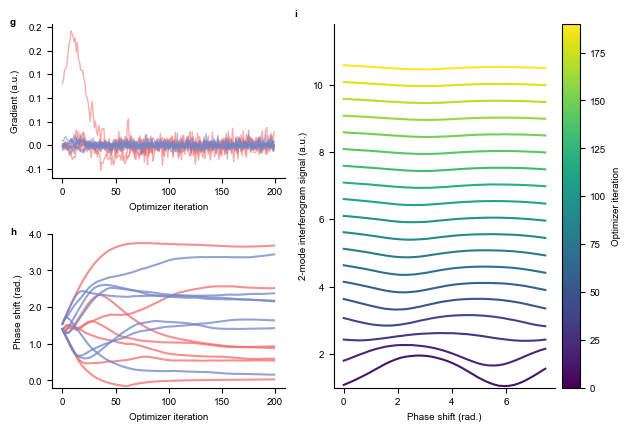

In [3]:
def channel_color(channel):
    if channel in theta_channels:
        return "#f26b6b"
    if channel in phi_channels:
        return "#7185c8"
    return "0.25"


fig = plt.figure(figsize=(6.2, 4.2), constrained_layout=True)
grid = fig.add_gridspec(2, 2, width_ratios=(1.05, 1.0))
ax_gradient = fig.add_subplot(grid[0, 0])
ax_phase = fig.add_subplot(grid[1, 0])
ax_interferogram = fig.add_subplot(grid[:, 1])

for column, channel in enumerate(channels):
    color = channel_color(channel)
    ax_gradient.plot(gradient[:, column], color=color, alpha=0.55, linewidth=1.0)
    ax_phase.plot(phase[:, column], color=color, alpha=0.75, linewidth=1.5)

ax_gradient.set_ylabel("Gradient (a.u.)")
ax_gradient.set_xlabel("Optimizer iteration")
ax_gradient.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

ax_phase.set_ylabel("Phase shift (rad.)")
ax_phase.set_xlabel("Optimizer iteration")
ax_phase.set_ylim(-0.2, 4.0)
ax_phase.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

# Interferograms were acquired every ten optimization steps. Curves are
# normalized by their mean and vertically offset so their evolution is visible.
offset = 0.5
indices = np.arange(1, interferogram_x.shape[0])
cmap = cm.viridis
norm = colors.Normalize(vmin=0, vmax=indices.max() * 10)
for index in indices:
    trace = interferogram_y[index] / np.mean(interferogram_y[index])
    trace = trace + offset * index
    ax_interferogram.plot(
        interferogram_x[index] * VOLTS_TO_RADIANS,
        trace,
        color=cmap(norm(index * 10)),
        linewidth=1.5,
    )

ax_interferogram.set_xlabel("Phase shift (rad.)")
ax_interferogram.set_ylabel("2-mode interferogram signal (a.u.)")
ax_interferogram.set_ylim(1.0, 11.8)
colorbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax_interferogram, pad=0.03)
colorbar.set_label("Optimizer iteration")

for label, axis in zip(("g", "h", "i"), (ax_gradient, ax_phase, ax_interferogram)):
    axis.text(-0.18, 1.04, label, transform=axis.transAxes, fontweight="bold", va="top")

fig.savefig(OUTPUT_DIR / "figure1_optimization_panels.png", dpi=300, bbox_inches="tight")
plt.show()